In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("data\\raw\\U.S._Chronic_Disease_Indicators.csv", low_memory=False)

def clean_chronic_disease_data(data):
    # 2. FILTERING BY METRIC CONSISTENCY
    # We only keep 'Crude Prevalence' to ensure all DataValues are on a 0-100% scale.
    # This prevents the model from trying to compare percentages with raw death counts.
    df_clean = data[data['DataValueType'] == 'Crude Prevalence'].copy()
    
    # 3. HANDLING MISSING TARGETS
    # If we don't have the DataValue (the prevalence %), the row is useless for training.
    df_clean = df_clean.dropna(subset=['DataValue'])
    
    # 4. GEOSPATIAL DATA EXTRACTION
    # The 'Geolocation' column is a string like 'POINT (-92.27 34.74)'. 
    # We need to split this into two float columns for the ML model to understand location.
    def extract_lat(point):
        try:
            return float(point.replace('POINT (', '').replace(')', '').split()[1])
        except:
            return np.nan

    def extract_long(point):
        try:
            return float(point.replace('POINT (', '').replace(')', '').split()[0])
        except:
            return np.nan

    df_clean['Latitude'] = df_clean['Geolocation'].apply(extract_lat)
    df_clean['Longitude'] = df_clean['Geolocation'].apply(extract_long)
    
    # Drop rows where Geolocation was missing (usually small territories)
    df_clean = df_clean.dropna(subset=['Latitude', 'Longitude'])
    
    # 5. STRATEGIC FEATURE SELECTION
    # We drop ID columns and redundant descriptions to reduce 'dimensionality curse'
    cols_to_drop = [
        'Response', 'ResponseID',                # Almost 100% null
        'DataValueAlt', 'DataValueUnit',         # Redundant (Unit is always %)
        'DataValueFootnoteSymbol', 'DataValueFootnote', # Meta-comments
        'LocationDesc', 'DataSource',            # Redundant with LocationAbbr
        'TopicID', 'QuestionID', 'LocationID',   # Redundant with the text columns
        'StratificationCategoryID1', 'StratificationID1',
        'StratificationCategory2', 'Stratification2', # Empty in this subset
        'StratificationCategory3', 'Stratification3', # Empty in this subset
        'Geolocation'                             # Now replaced by Lat/Long
    ]
    
    df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
    
    # 6. FILTERING OUT CONFIDENCE INTERVALS FOR INPUT
    # Low/High Confidence Limits are 'calculated' from the DataValue. 
    # Keeping them in features would be 'Data Leakage' (cheating).
    df_clean = df_clean.drop(columns=['LowConfidenceLimit', 'HighConfidenceLimit','StratificationCategoryID2','StratificationCategoryID3','StratificationID3','StratificationID2'])
    
    return df_clean

# Execute the cleaning
df = clean_chronic_disease_data(df)

print(f"Original Rows: {len(df)}")
print("----------------------------------------")
#print(f"Cleaned Rows: {len(df_final)}")
print(df.head())

Original Rows: 85619
----------------------------------------
   YearStart  YearEnd LocationAbbr          Topic  \
0       2019     2019           AR       Diabetes   
1       2019     2019           ID       Diabetes   
4       2019     2019           IA         Asthma   
7       2019     2019           IA  Mental Health   
9       2019     2019           LA  Mental Health   

                      Question     DataValueType  DataValue  \
0        Diabetes among adults  Crude Prevalence       13.6   
1        Diabetes among adults  Crude Prevalence       10.6   
4  Current asthma among adults  Crude Prevalence       10.3   
7      Depression among adults  Crude Prevalence       31.0   
9      Depression among adults  Crude Prevalence       29.3   

  StratificationCategory1            Stratification1 DataValueTypeID  \
0                     Sex                       Male         CRDPREV   
1                     Sex                       Male         CRDPREV   
4                     Ag

d:\Softwares\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster Assignment Sample:


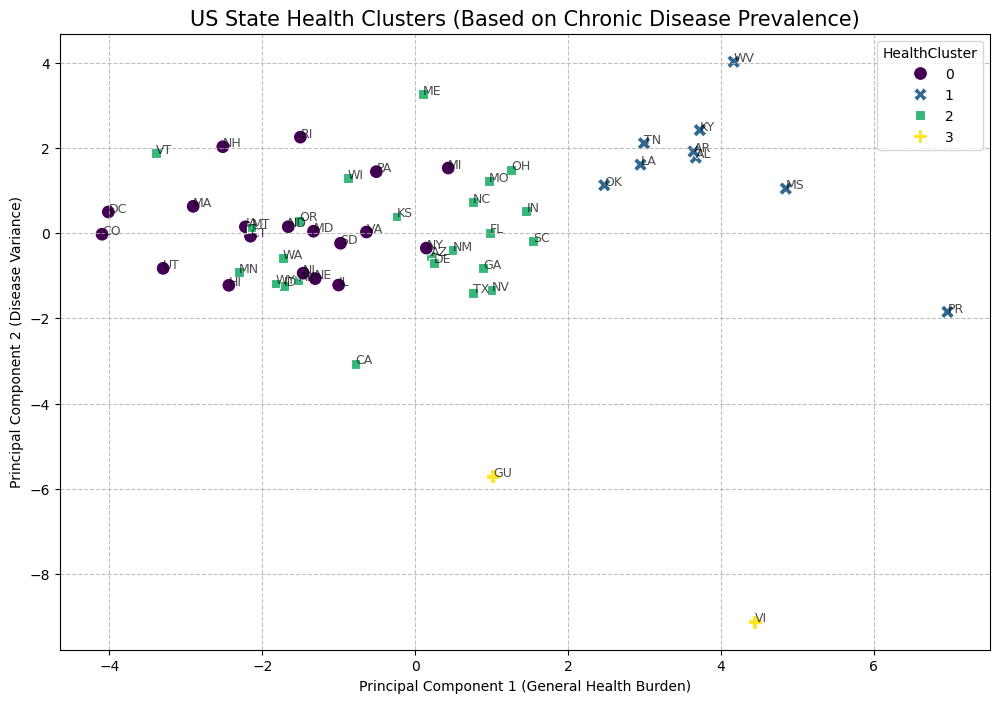

In [5]:
# 2. DATA PREPARATION (The "Basis" of Clustering)
# We create a state profile: mean prevalence of each disease topic per state
state_profiles = df.pivot_table(
    index='LocationAbbr', 
    columns='Topic', 
    values='DataValue', 
    aggfunc='mean'
).fillna(0)

# 3. FEATURE SCALING
# Essential for K-Means to ensure one disease doesn't dominate due to higher raw numbers
scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(state_profiles)

# 4. PERFORM K-MEANS CLUSTERING
# We chose 4 clusters to represent distinct health 'archetypes' in the US
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
state_profiles['HealthCluster'] = kmeans.fit_predict(profiles_scaled)

print("Cluster Assignment Sample:")
state_profiles['HealthCluster'].head()

# 5. VISUALIZATION (Using PCA to see 10D data in 2D)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(profiles_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=pca_results[:, 0], y=pca_results[:, 1], 
    hue=state_profiles['HealthCluster'], 
    palette='viridis', s=100, style=state_profiles['HealthCluster']
)

# Annotate the points with State Abbreviations
for i, state in enumerate(state_profiles.index):
    plt.annotate(state, (pca_results[i, 0], pca_results[i, 1]), fontsize=9, alpha=0.7)

plt.title('US State Health Clusters (Based on Chronic Disease Prevalence)', fontsize=15)
plt.xlabel('Principal Component 1 (General Health Burden)')
plt.ylabel('Principal Component 2 (Disease Variance)')
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

In [6]:
state_profiles

Topic,Alcohol,Arthritis,Asthma,Cancer,Cardiovascular Disease,Chronic Obstructive Pulmonary Disease,Cognitive Health and Caregiving,Diabetes,Disability,Health Status,Immunization,Maternal Health,Mental Health,"Nutrition, Physical Activity, and Weight Status",Oral Health,Sleep,Social Determinants of Health,Tobacco,HealthCluster
LocationAbbr,,,,,,,,,,,,,,,,,,,
AK,17.110606,30.180159,10.808571,64.833333,38.314458,17.437736,22.721212,11.909615,27.954545,14.302542,41.070635,85.116667,16.032609,25.611111,54.817213,44.756897,42.961111,24.771818,2
AL,14.525373,36.935200,10.767742,72.821053,47.360759,22.521429,27.042424,14.257447,36.030952,21.414159,41.241026,89.050000,21.568627,26.548289,51.012613,54.356452,45.527841,21.627481,1
AR,15.917778,36.893893,10.800000,64.650000,46.930488,23.717544,28.112903,13.507547,38.454545,21.953226,44.308943,86.016667,22.808257,26.936934,50.329915,54.729231,52.796923,23.251007,1
AZ,16.692473,32.283221,11.051220,64.550000,41.132258,16.103509,25.147826,14.004348,29.950000,16.965909,42.217007,84.183333,18.817757,22.860067,53.283193,50.898507,41.895028,18.146043,2
CA,14.304412,30.896667,9.830952,62.737037,41.083516,11.040351,20.997619,12.934091,26.925532,15.364234,44.960000,0.000000,14.806667,24.739474,54.458559,41.920000,36.600565,21.017241,2
CO,18.790526,28.463043,11.343243,64.741379,36.879348,15.155357,23.462500,8.576923,23.781250,14.120455,49.276471,90.771429,18.523684,21.033798,56.891057,45.496970,50.208966,19.919355,0
CT,14.257778,30.171324,12.164103,72.041667,42.001190,13.611321,23.289583,11.898361,25.206977,14.306957,48.234351,93.083333,16.264602,22.248551,57.585484,49.792424,48.763542,17.424490,0
DC,17.736842,30.138938,12.568571,71.919048,38.415584,12.580851,26.457143,9.489130,23.061538,12.188119,51.516807,90.166667,17.403810,21.581974,58.788696,49.653731,46.538095,16.146099,0
DE,14.108197,32.419835,10.748485,70.323810,44.202469,15.953846,22.496774,13.698039,27.202500,16.354464,46.154400,88.453333,14.708602,28.581910,53.898347,47.070370,48.250000,23.639837,2


In [78]:
# while creating the state profiles we treated LocationAbbr as index,now we are resetting the index if not we get the KeyIndex Not found error.
state_profiles = state_profiles.reset_index()

#combine back the Healthcluster to our data based on LocationAbbr
df=pd.merge(df,state_profiles[['LocationAbbr','HealthCluster']], on ='LocationAbbr',how='left')
df

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValueType,DataValue,StratificationCategory1,Stratification1,DataValueTypeID,Latitude,Longitude,HealthCluster
0,2019,2019,AR,Diabetes,Diabetes among adults,Crude Prevalence,13.6,Sex,Male,CRDPREV,34.748650,-92.274491,1
1,2019,2019,ID,Diabetes,Diabetes among adults,Crude Prevalence,10.6,Sex,Male,CRDPREV,43.682630,-114.363730,2
2,2019,2019,IA,Asthma,Current asthma among adults,Crude Prevalence,10.3,Age,Age 18-44,CRDPREV,42.469401,-93.816491,0
3,2019,2019,IA,Mental Health,Depression among adults,Crude Prevalence,31.0,Race/Ethnicity,"Multiracial, non-Hispanic",CRDPREV,42.469401,-93.816491,0
4,2019,2019,LA,Mental Health,Depression among adults,Crude Prevalence,29.3,Race/Ethnicity,Hispanic,CRDPREV,31.312661,-92.445680,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85614,2022,2022,WA,Health Status,2 or more chronic conditions among adults,Crude Prevalence,19.7,Sex,Female,CRDPREV,47.522279,-120.470011,2
85615,2022,2022,VT,Sleep,Short sleep duration among adults,Crude Prevalence,26.5,Race/Ethnicity,"Asian, non-Hispanic",CRDPREV,43.625381,-72.517641,2
85616,2022,2022,VI,Immunization,Influenza vaccination among adults,Crude Prevalence,34.2,Age,Age >=65,CRDPREV,18.335765,-64.896335,3
85617,2022,2022,WV,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,Crude Prevalence,14.0,Overall,Overall,CRDPREV,38.665510,-80.712640,1


In [ ]:
state_profiles

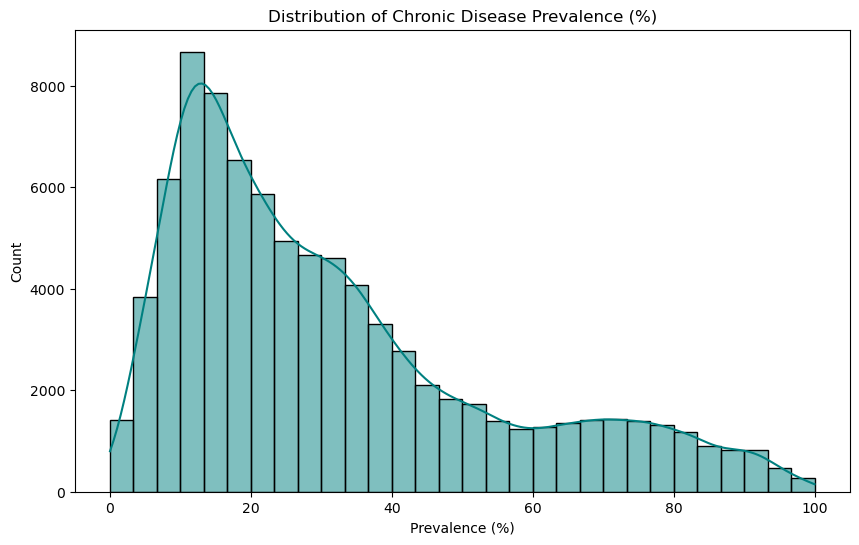

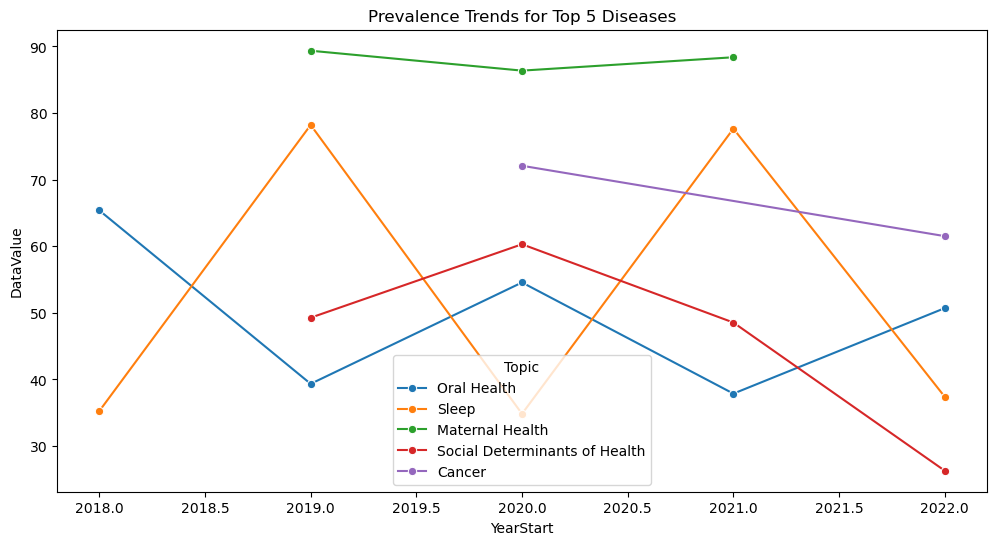

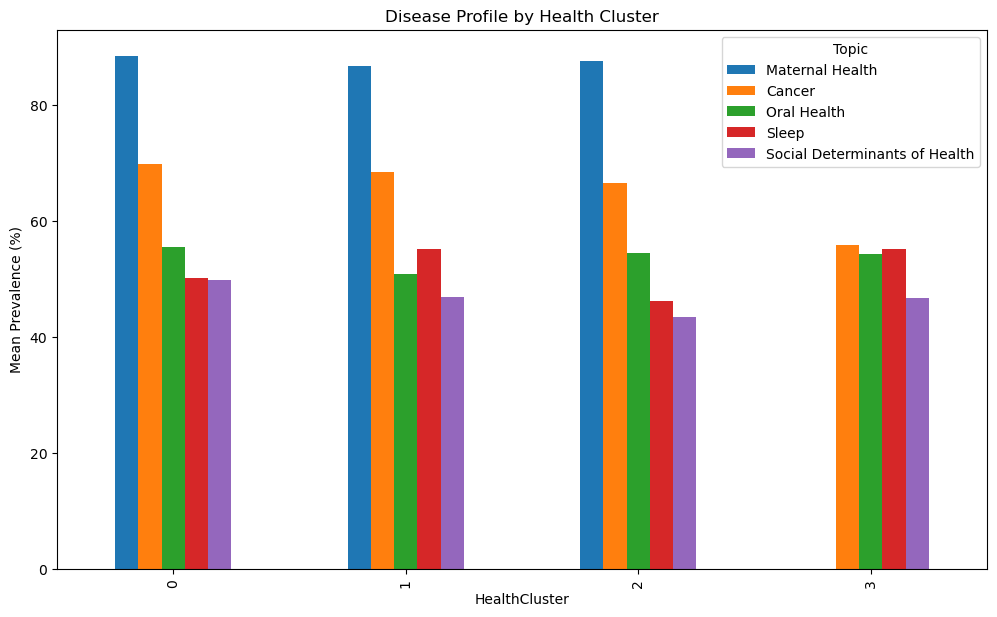

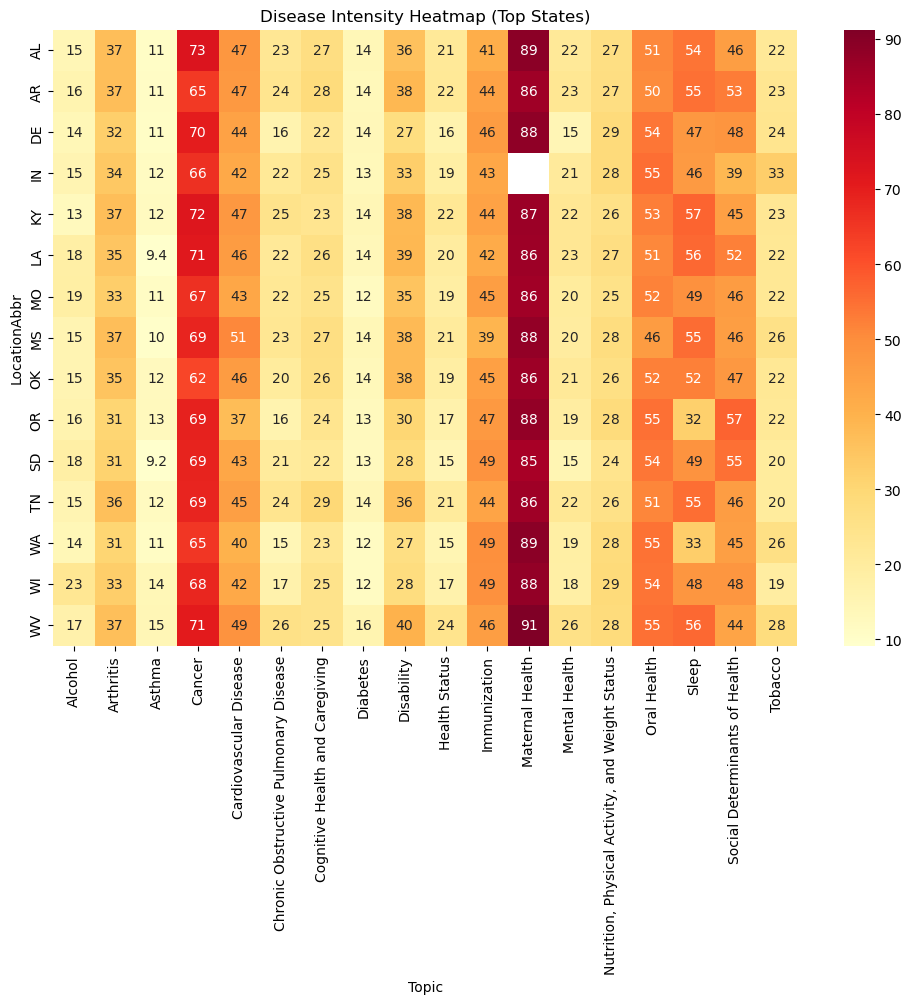

In [79]:
# --- 1. PREVALENCE DISTRIBUTION ---
plt.figure(figsize=(10, 6))
sns.histplot(df['DataValue'], bins=30, kde=True, color='teal')
plt.title('Distribution of Chronic Disease Prevalence (%)')
plt.xlabel('Prevalence (%)')
plt.savefig('eda_prevalence_distribution.png')

# --- 2. TOP 5 TOPICS OVER TIME ---
top_5 = df.groupby('Topic')['DataValue'].mean().nlargest(5).index
df_trends = df[df['Topic'].isin(top_5)].groupby(['YearStart', 'Topic'])['DataValue'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='YearStart', y='DataValue', hue='Topic', marker='o')
plt.title('Prevalence Trends for Top 5 Diseases')
plt.savefig('eda_topic_trends.png')

# --- 3. CLUSTER SIGNATURES ---
pivot_clusters = df.pivot_table(index='HealthCluster', columns='Topic', values='DataValue', aggfunc='mean')
pivot_clusters[top_5].plot(kind='bar', figsize=(12, 7))
plt.title('Disease Profile by Health Cluster')
plt.ylabel('Mean Prevalence (%)')
plt.savefig('eda_cluster_comparison.png')

# --- 4. STATE-TOPIC HEATMAP ---
top_states = df.groupby('LocationAbbr')['DataValue'].mean().nlargest(15).index
heatmap_pivot = df[df['LocationAbbr'].isin(top_states)].pivot_table(
    index='LocationAbbr', columns='Topic', values='DataValue', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot, annot=True, cmap='YlOrRd')
plt.title('Disease Intensity Heatmap (Top States)')
plt.savefig('eda_state_disease_heatmap.png')

In [81]:
#CHeck if there are any missing values in the data before proceeding with the model build
df.isna().sum()

YearStart                  0
YearEnd                    0
LocationAbbr               0
Topic                      0
Question                   0
DataValueType              0
DataValue                  0
StratificationCategory1    0
Stratification1            0
DataValueTypeID            0
Latitude                   0
Longitude                  0
HealthCluster              0
dtype: int64

In [89]:
df

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValueType,DataValue,StratificationCategory1,Stratification1,DataValueTypeID,Latitude,Longitude,HealthCluster
0,2019,2019,AR,Diabetes,Diabetes among adults,Crude Prevalence,13.6,Sex,Male,CRDPREV,34.748650,-92.274491,1
1,2019,2019,ID,Diabetes,Diabetes among adults,Crude Prevalence,10.6,Sex,Male,CRDPREV,43.682630,-114.363730,2
2,2019,2019,IA,Asthma,Current asthma among adults,Crude Prevalence,10.3,Age,Age 18-44,CRDPREV,42.469401,-93.816491,0
3,2019,2019,IA,Mental Health,Depression among adults,Crude Prevalence,31.0,Race/Ethnicity,"Multiracial, non-Hispanic",CRDPREV,42.469401,-93.816491,0
4,2019,2019,LA,Mental Health,Depression among adults,Crude Prevalence,29.3,Race/Ethnicity,Hispanic,CRDPREV,31.312661,-92.445680,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85614,2022,2022,WA,Health Status,2 or more chronic conditions among adults,Crude Prevalence,19.7,Sex,Female,CRDPREV,47.522279,-120.470011,2
85615,2022,2022,VT,Sleep,Short sleep duration among adults,Crude Prevalence,26.5,Race/Ethnicity,"Asian, non-Hispanic",CRDPREV,43.625381,-72.517641,2
85616,2022,2022,VI,Immunization,Influenza vaccination among adults,Crude Prevalence,34.2,Age,Age >=65,CRDPREV,18.335765,-64.896335,3
85617,2022,2022,WV,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,Crude Prevalence,14.0,Overall,Overall,CRDPREV,38.665510,-80.712640,1


Text(0.5, 1.0, 'Correlation Matrix')

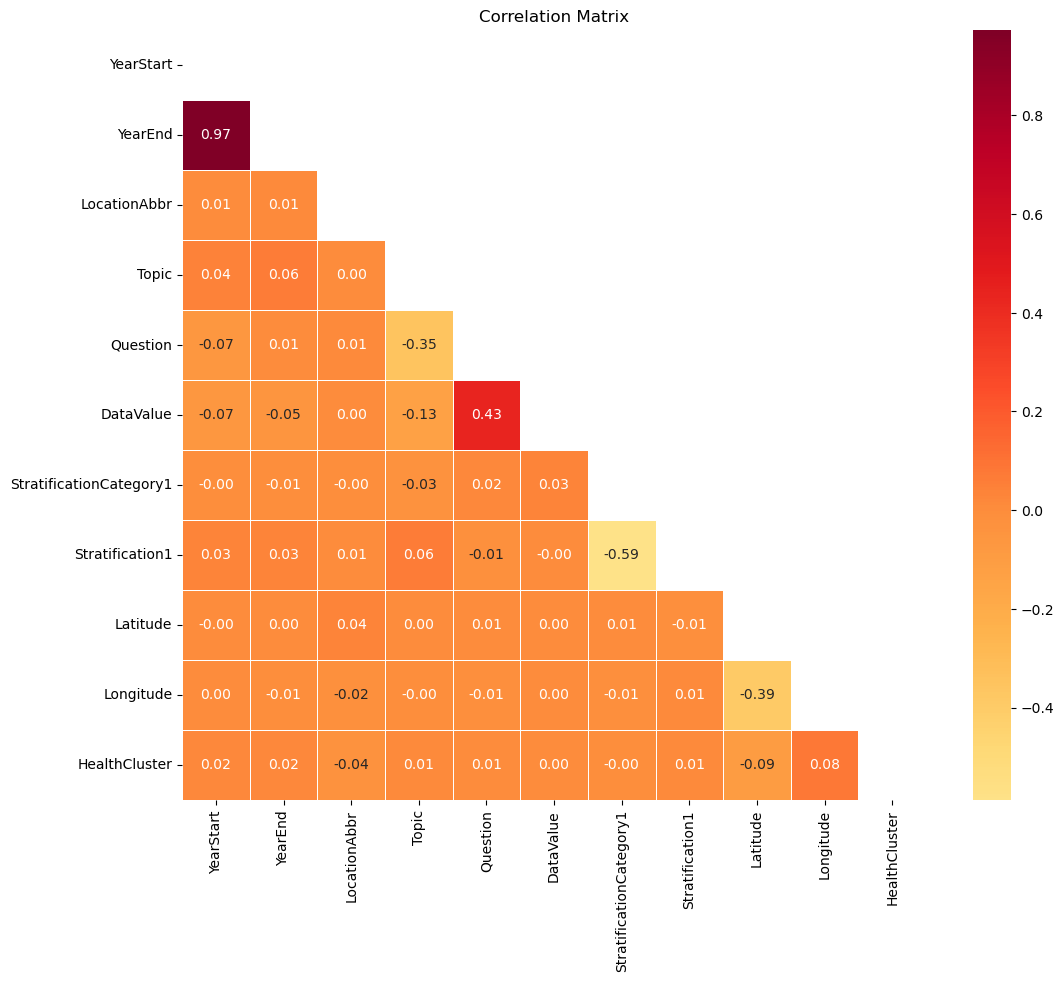

In [101]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr,dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt = ".2f",center=0,linewidth=.5,cmap='YlOrRd',mask=mask)
plt.title('Correlation Matrix')


In [ ]:
# 3. Label Encoding for Categorical Features
le = LabelEncoder()
for col in ['LocationAbbr', 'Topic', 'Question', 'Stratification1','StratificationCategory1']:
    df[col] = le.fit_transform(df[col].astype(str))
df

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValueType,DataValue,StratificationCategory1,Stratification1,DataValueTypeID,Latitude,Longitude,HealthCluster
0,2019,2019,12,15,19,Crude Prevalence,13.6,4,14,CRDPREV,34.748650,-92.274491,1
1,2019,2019,6,15,19,Crude Prevalence,10.6,4,14,CRDPREV,43.682630,-114.363730,2
2,2019,2019,5,10,10,Crude Prevalence,10.3,0,18,CRDPREV,42.469401,-93.816491,0
3,2019,2019,5,4,18,Crude Prevalence,31.0,3,15,CRDPREV,42.469401,-93.816491,0
4,2019,2019,11,4,18,Crude Prevalence,29.3,3,13,CRDPREV,31.312661,-92.445680,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85614,2022,2022,46,17,0,Crude Prevalence,19.7,4,6,CRDPREV,47.522279,-120.470011,2
85615,2022,2022,44,7,66,Crude Prevalence,26.5,3,4,CRDPREV,43.625381,-72.517641,2
85616,2022,2022,43,2,36,Crude Prevalence,34.2,0,24,CRDPREV,18.335765,-64.896335,3
85617,2022,2022,48,13,2,Crude Prevalence,14.0,2,16,CRDPREV,38.665510,-80.712640,1


In [95]:
df.drop(columns=['DataValueType','DataValueTypeID'],inplace=True)
df

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValue,StratificationCategory1,Stratification1,Latitude,Longitude,HealthCluster
0,2019,2019,12,15,19,13.6,4,14,34.748650,-92.274491,1
1,2019,2019,6,15,19,10.6,4,14,43.682630,-114.363730,2
2,2019,2019,5,10,10,10.3,0,18,42.469401,-93.816491,0
3,2019,2019,5,4,18,31.0,3,15,42.469401,-93.816491,0
4,2019,2019,11,4,18,29.3,3,13,31.312661,-92.445680,1
...,...,...,...,...,...,...,...,...,...,...,...
85614,2022,2022,46,17,0,19.7,4,6,47.522279,-120.470011,2
85615,2022,2022,44,7,66,26.5,3,4,43.625381,-72.517641,2
85616,2022,2022,43,2,36,34.2,0,24,18.335765,-64.896335,3
85617,2022,2022,48,13,2,14.0,2,16,38.665510,-80.712640,1


In [97]:
df.corr()

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValue,StratificationCategory1,Stratification1,Latitude,Longitude,HealthCluster
YearStart,1.000000,0.973081,0.009654,0.044642,-0.068529,-0.066697,-0.003417,0.032645,-0.002078,0.001221,0.018336
YearEnd,0.973081,1.000000,0.012591,0.064085,0.005782,-0.045425,-0.007042,0.031925,0.001238,-0.005605,0.017606
LocationAbbr,0.009654,0.012591,1.000000,0.003643,0.011745,0.003270,-0.003454,0.008399,0.040492,-0.018574,-0.035967
Topic,0.044642,0.064085,0.003643,1.000000,-0.351563,-0.133473,-0.026841,0.063434,0.004933,-0.004230,0.013973
Question,-0.068529,0.005782,0.011745,-0.351563,1.000000,0.431538,0.019279,-0.014343,0.005611,-0.009930,0.007051
DataValue,-0.066697,-0.045425,0.003270,-0.133473,0.431538,1.000000,0.031202,-0.001820,0.004431,0.001910,0.003307
StratificationCategory1,-0.003417,-0.007042,-0.003454,-0.026841,0.019279,0.031202,1.000000,-0.587230,0.006681,-0.009742,-0.004518
Stratification1,0.032645,0.031925,0.008399,0.063434,-0.014343,-0.001820,-0.587230,1.000000,-0.008963,0.011809,0.012551
Latitude,-0.002078,0.001238,0.040492,0.004933,0.005611,0.004431,0.006681,-0.008963,1.000000,-0.389144,-0.088989
Longitude,0.001221,-0.005605,-0.018574,-0.004230,-0.009930,0.001910,-0.009742,0.011809,-0.389144,1.000000,0.079530


Text(0.5, 1.0, 'Correlation Matrix')

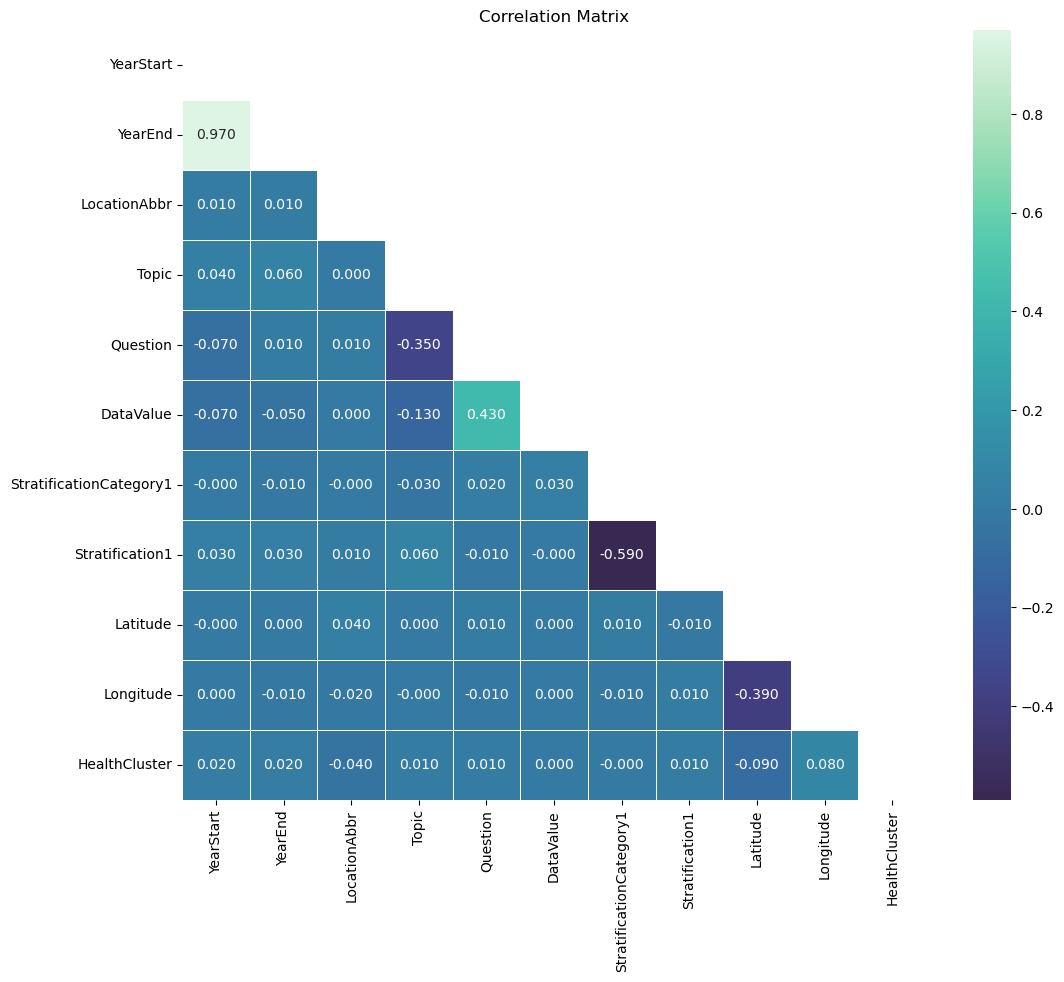

In [107]:
corr = df.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(corr,dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt = ".3f",center=0,linewidth=.5,cmap='mako',mask=mask)
plt.title('Correlation Matrix')

In [ ]:
cols = ['YearStart', 'LocationAbbr', 'Topic', 'Question', 'Stratification1','StratificationCategory1','HealthCluster']
X = df[cols].copy()
y = df['DataValue']


# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100,max_depth=15,min_samples_leaf=2, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

print("--- Starting Model Training and Evaluation ---")

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    # Store results
    results.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })
    
    print(f"Finished: {name}")

# 6. Display Comparison Table
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("\n--- Final Model Comparison ---")
results_df




--- Starting Model Training and Evaluation ---
Finished: Linear Regression
Finished: Random Forest
Finished: Gradient Boosting

--- Final Model Comparison ---


,Model,MAE,RMSE,R2 Score
1,Random Forest,2.9298,4.3548,0.9639
2,Gradient Boosting,7.3982,9.7447,0.8195
0,Linear Regression,16.1085,20.5728,0.1954


While the model achieved a high $R^2$ score, the residual analysis showed a 'widespread' pattern (heteroscedasticity). This suggests that while we can predict broad trends, local-level 'stochastic' factors—like a specific city's water quality or a local health policy change—create noise that a national-level model cannot fully capture.

In [131]:

features =X.columns

# 7. Bonus: Get Feature Importance from the Champion Model (Random Forest)
final_model = models["Random Forest"]
importances = final_model.feature_importances_
feat_importance = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance (Random Forest) ---")
print(feat_importance)


--- Feature Importance (Random Forest) ---
                   Feature  Importance
3                 Question    0.773101
2                    Topic    0.122654
4          Stratification1    0.052917
1             LocationAbbr    0.023631
6            HealthCluster    0.011929
0                YearStart    0.008258
5  StratificationCategory1    0.007510


In [132]:
from sklearn.model_selection import cross_val_score
cv_rf =  models["Random Forest"]
cv_scores = cross_val_score(cv_rf,X,y,cv=5,scoring='r2')
print(f"All CV r2 scores:{cv_scores}")
print(f"Mean R2 score:{cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

All CV r2 scores:[0.95491871 0.96006969 0.96607281 0.96445017 0.82862238]
Mean R2 score:0.9348
Standard Deviation: 0.0532


While the model achieved a high $R^2$ score, the residual analysis showed a 'widespread' pattern (heteroscedasticity). This suggests that while we can predict broad trends, local-level 'stochastic' factors—like a specific city's water quality or a local health policy change—create noise that a national-level model cannot fully capture.

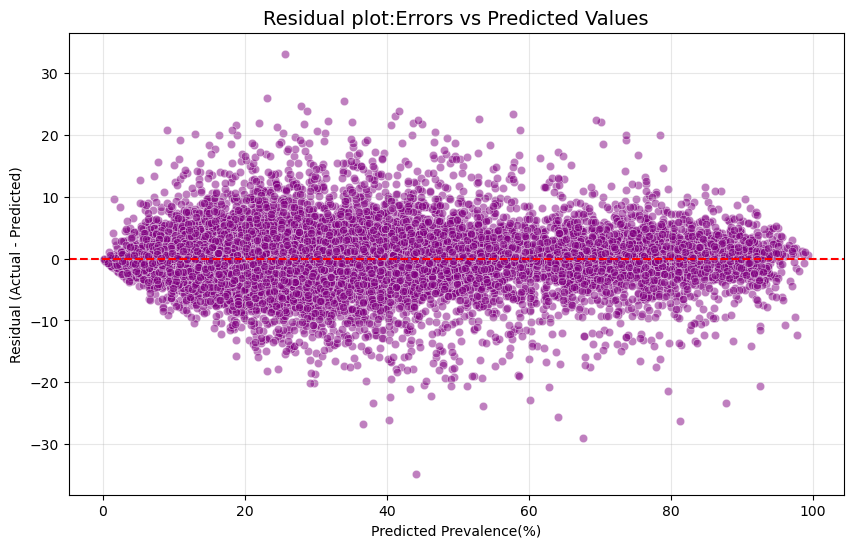

In [134]:
y_pred = final_model.predict(X_test)
residuals = y_test - y_pred
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred,y=residuals,alpha=0.5,color='purple')
plt.axhline(0,color='red',linestyle='--')
plt.title("Residual plot:Errors vs Predicted Values",fontsize=14)
plt.xlabel("Predicted Prevalence(%)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True,alpha=0.3)


### Future Steps: 
To improve the model's predictive power, the next phase would involve merging this dataset with Social Determinants of Health (SDoH). Integrating variables like 'Median Household Income' or 'Percentage of Population with Insurance' by zip code would likely tighten the residual spread and provide a more nuanced understanding of why certain clusters exist